In [2]:
from pathlib import Path
import os
import random
import shutil
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter

from ultralytics import YOLO

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
PROJECT_DIR = Path.cwd()
DATASET_DIR = PROJECT_DIR / "vechile_detection"

print("Project:", PROJECT_DIR)
print("Dataset:", DATASET_DIR)
print("Dataset exists:", DATASET_DIR.exists())

Project: C:\Users\lenovo\downloads\ANPR_Traffic_AI
Dataset: C:\Users\lenovo\downloads\ANPR_Traffic_AI\vechile_detection
Dataset exists: True


In [4]:
for item in DATASET_DIR.iterdir():
    print(item.name)

100Ambulance.jpg
100Ambulance.txt
100car.jpg
100car.txt
100Truck.jpg
100Truck.txt
101Ambulance.jpg
101Ambulance.txt
101car.jpg
101car.txt
101Truck.jpg
101Truck.txt
102Ambulance.jpg
102Ambulance.txt
102car.jpg
102car.txt
102Truck.jpg
102Truck.txt
103Ambulance.jpg
103Ambulance.txt
103car.jpg
103car.txt
103Truck.jpg
103Truck.txt
104Ambulance.jpg
104Ambulance.txt
104car.jpg
104car.txt
104Truck.jpg
104Truck.txt
105Ambulance.jpg
105Ambulance.txt
105car.jpg
105car.txt
105Truck.jpg
105Truck.txt
106Ambulance.jpg
106Ambulance.txt
106car.jpg
106car.txt
106Truck.jpg
106Truck.txt
107Ambulance.jpg
107Ambulance.txt
107car.jpg
107car.txt
107Truck.jpg
107Truck.txt
108Ambulance.jpg
108Ambulance.txt
108car.jpg
108car.txt
108Truck.jpg
108Truck.txt
109Ambulance.jpg
109Ambulance.txt
109car.jpg
109car.txt
109Truck.jpg
109Truck.txt
10Ambulance.jpg
10Ambulance.txt
10car.jpg
10car.txt
10Truck.jpg
10Truck.txt
110Ambulance.jpg
110Ambulance.txt
110car.jpg
110car.txt
110Truck.jpg
110Truck.txt
111Ambulance.jpg
111Am

In [5]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

image_files = [
    p for p in DATASET_DIR.iterdir()
    if p.suffix.lower() in IMAGE_EXTENSIONS
]

label_files = [
    p for p in DATASET_DIR.glob("*.txt")
    if p.name not in ["train.txt", "test.txt", "classes.txt"]
]

print("Total images:", len(image_files))
print("Total label files:", len(label_files))

Total images: 556
Total label files: 556


In [6]:
classes_file = DATASET_DIR / "classes.txt"

classes = [
    line.strip()
    for line in classes_file.read_text(encoding="utf-8").splitlines()
    if line.strip()
]

print("Classes:")

for i, cls in enumerate(classes):
    print(f"{i} → {cls}")

print("\nNumber of classes:", len(classes))

Classes:
0 → Ambulance
1 → Bus
2 → Car
3 → Truck

Number of classes: 4


In [7]:
sample_label = label_files[0]

print("Sample label:", sample_label.name)
print("-" * 50)

print(sample_label.read_text(encoding="utf-8"))

Sample label: 100Ambulance.txt
--------------------------------------------------



In [8]:
bad_labels = []
object_counts = Counter()

for label_path in label_files:

    try:
        lines = label_path.read_text(encoding="utf-8").splitlines()

        for line in lines:

            parts = line.strip().split()

            if len(parts) != 5:
                bad_labels.append(
                    (label_path.name, "Wrong number of values")
                )
                continue

            class_id = int(parts[0])
            x, y, w, h = map(float, parts[1:])

            if class_id < 0 or class_id >= len(classes):
                bad_labels.append(
                    (label_path.name, "Invalid class ID")
                )

            if not all(0 <= value <= 1 for value in [x, y, w, h]):
                bad_labels.append(
                    (label_path.name, "Coordinates outside 0-1")
                )

            object_counts[class_id] += 1

    except Exception as e:
        bad_labels.append((label_path.name, str(e)))


print("Annotation validation completed.")
print("Bad annotations:", len(bad_labels))

print("\nObjects per class:")

for class_id, count in sorted(object_counts.items()):
    print(f"{classes[class_id]}: {count}")

Annotation validation completed.
Bad annotations: 0

Objects per class:
Ambulance: 119
Bus: 172
Car: 161
Truck: 125


In [9]:
missing_labels = []

for image_path in image_files:

    label_path = image_path.with_suffix(".txt")

    if not label_path.exists():
        missing_labels.append(image_path.name)

print("Images without labels:", len(missing_labels))

if missing_labels:
    print(missing_labels[:10])

Images without labels: 0


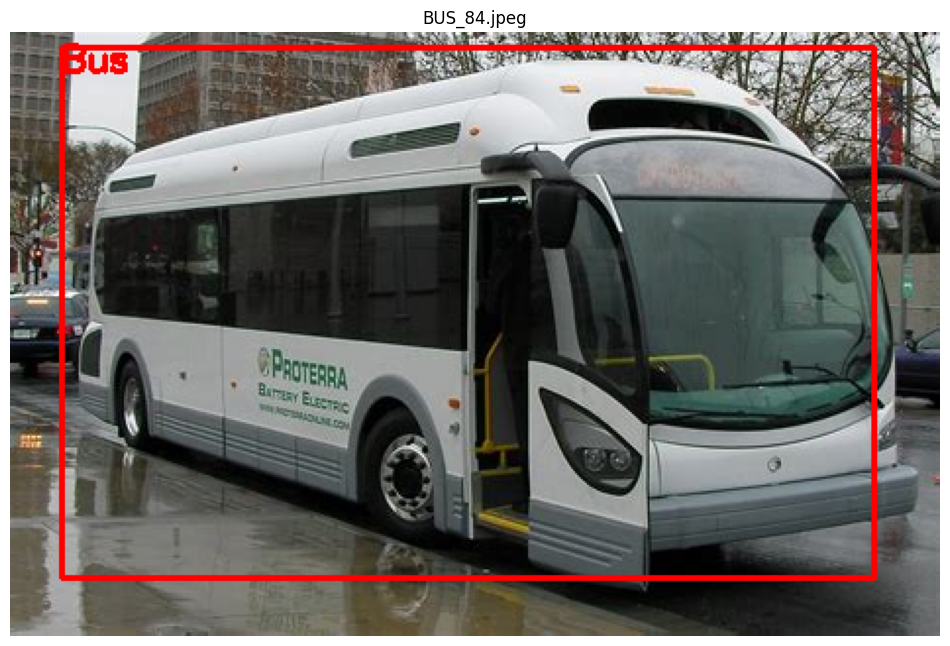

In [10]:
sample_image = random.choice(image_files)
sample_label = sample_image.with_suffix(".txt")

image = cv2.imread(str(sample_image))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

height, width = image.shape[:2]

with open(sample_label, "r") as f:

    for line in f:

        parts = line.strip().split()

        if len(parts) != 5:
            continue

        class_id, x, y, box_w, box_h = map(float, parts)

        x1 = int((x - box_w / 2) * width)
        y1 = int((y - box_h / 2) * height)

        x2 = int((x + box_w / 2) * width)
        y2 = int((y + box_h / 2) * height)

        cv2.rectangle(
            image,
            (x1, y1),
            (x2, y2),
            (255, 0, 0),
            2
        )

        cv2.putText(
            image,
            classes[int(class_id)],
            (x1, max(20, y1 - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            2
        )

plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis("off")
plt.title(sample_image.name)
plt.show()

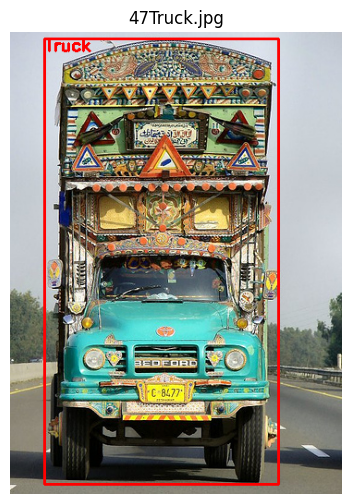

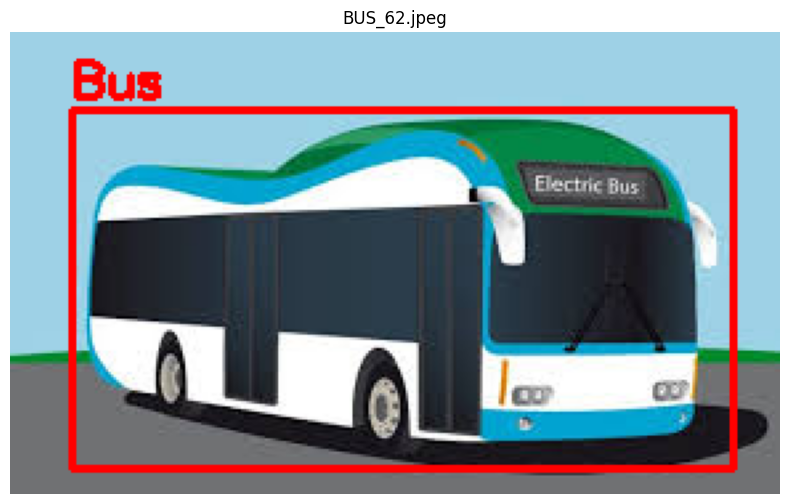

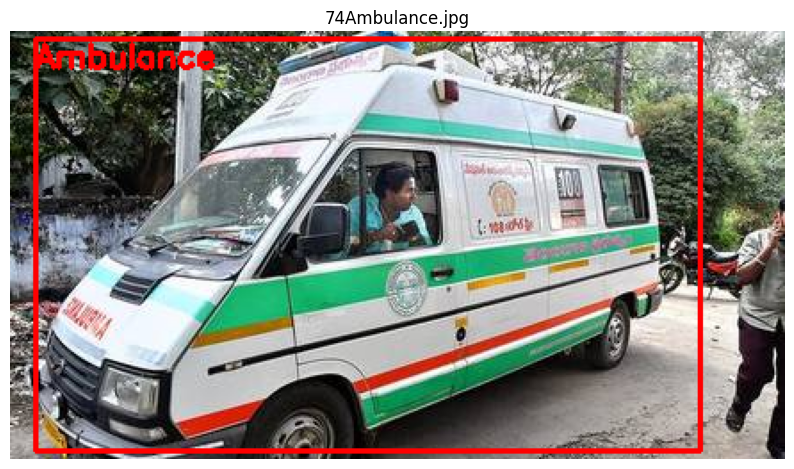

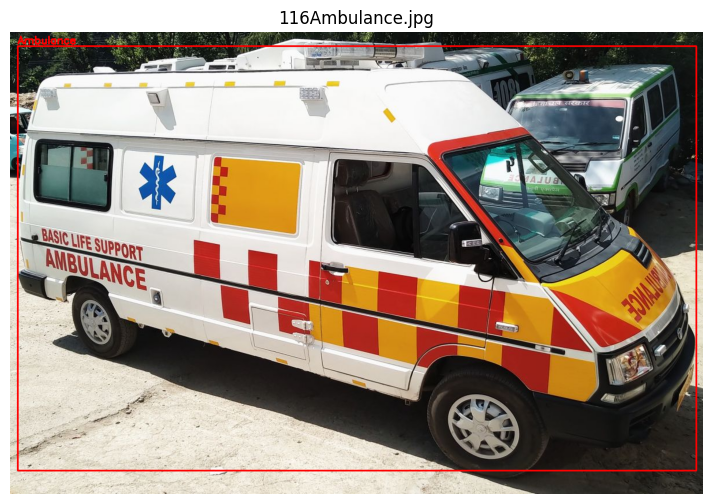

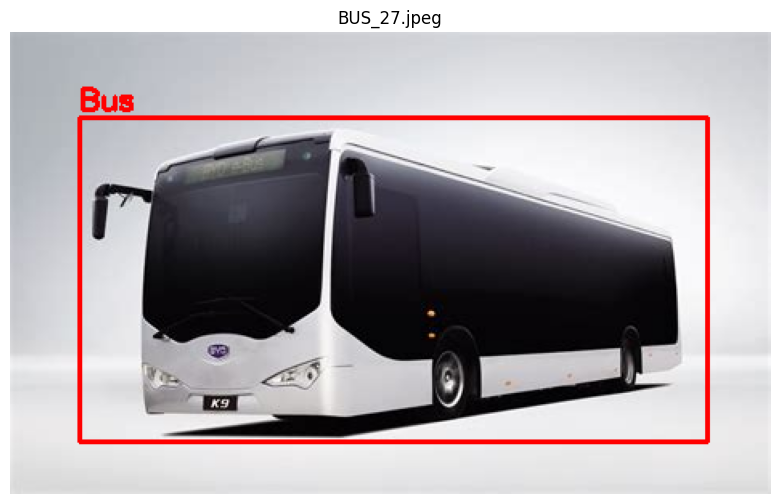

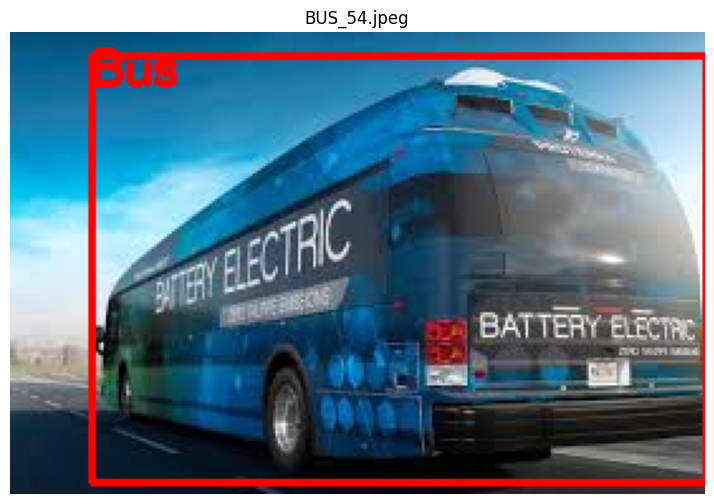

In [11]:
sample_images = random.sample(
    image_files,
    min(6, len(image_files))
)

for sample_image in sample_images:

    sample_label = sample_image.with_suffix(".txt")

    image = cv2.imread(str(sample_image))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    height, width = image.shape[:2]

    with open(sample_label, "r") as f:

        for line in f:

            parts = line.strip().split()

            if len(parts) != 5:
                continue

            class_id, x, y, box_w, box_h = map(float, parts)

            x1 = int((x - box_w / 2) * width)
            y1 = int((y - box_h / 2) * height)
            x2 = int((x + box_w / 2) * width)
            y2 = int((y + box_h / 2) * height)

            cv2.rectangle(
                image,
                (x1, y1),
                (x2, y2),
                (255, 0, 0),
                2
            )

            cv2.putText(
                image,
                classes[int(class_id)],
                (x1, max(20, y1 - 5)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 0, 0),
                2
            )

    plt.figure(figsize=(10, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(sample_image.name)
    plt.show()

In [12]:
train_txt = DATASET_DIR / "train.txt"
test_txt = DATASET_DIR / "test.txt"

print("train.txt exists:", train_txt.exists())
print("test.txt exists:", test_txt.exists())

print("\nFirst 5 train entries:")
print("\n".join(train_txt.read_text(encoding="utf-8").splitlines()[:5]))

print("\nFirst 5 test entries:")
print("\n".join(test_txt.read_text(encoding="utf-8").splitlines()[:5]))

train.txt exists: True
test.txt exists: True

First 5 train entries:
training_image/116car.jpg
training_image/118car.jpg
training_image/118Ambulance.jpg
training_image/117car.jpg
training_image/120car.jpg

First 5 test entries:
training_image/116car.jpg
training_image/118car.jpg
training_image/118Ambulance.jpg
training_image/117car.jpg
training_image/120car.jpg


In [13]:
YOLO_DATASET = DATASET_DIR / "yolo_dataset"

for folder in [
    YOLO_DATASET / "images" / "train",
    YOLO_DATASET / "images" / "val",
    YOLO_DATASET / "labels" / "train",
    YOLO_DATASET / "labels" / "val"
]:
    folder.mkdir(parents=True, exist_ok=True)

print("YOLO dataset folders created.")

YOLO dataset folders created.


In [17]:
def find_image(filename):
    matches = list(DATASET_DIR.rglob(Path(filename).name))
    
    if matches:
        return matches[0]
    
    return None


def read_image_list(txt_file):
    paths = []

    for line in txt_file.read_text(encoding="utf-8").splitlines():

        line = line.strip()

        if not line:
            continue

        filename = Path(line).name
        image_path = find_image(filename)

        if image_path is not None:
            paths.append(image_path)

    return paths


train_list = read_image_list(train_txt)
test_list = read_image_list(test_txt)

print("Train images found:", len(train_list))
print("Test images found:", len(test_list))

Train images found: 556
Test images found: 83


In [18]:
print("Train images found:", len(train_list))
print("Test images found:", len(test_list))

print("\nExample train image:")
print(train_list[0] if train_list else "None")

print("\nExample test image:")
print(test_list[0] if test_list else "None")

Train images found: 556
Test images found: 83

Example train image:
C:\Users\lenovo\downloads\ANPR_Traffic_AI\vechile_detection\116car.jpg

Example test image:
C:\Users\lenovo\downloads\ANPR_Traffic_AI\vechile_detection\116car.jpg


In [19]:
random.seed(42)

all_images = list(set(train_list))

random.shuffle(all_images)

split_index = int(0.8 * len(all_images))

final_train_list = all_images[:split_index]
final_val_list = all_images[split_index:]

print("Total unique images:", len(all_images))
print("Training images:", len(final_train_list))
print("Validation images:", len(final_val_list))

Total unique images: 556
Training images: 444
Validation images: 112


In [20]:
train_names = {p.name for p in final_train_list}
val_names = {p.name for p in final_val_list}

overlap = train_names.intersection(val_names)

print("Training images:", len(train_names))
print("Validation images:", len(val_names))
print("Overlap:", len(overlap))

Training images: 444
Validation images: 112
Overlap: 0


In [21]:
YOLO_DATASET = DATASET_DIR / "yolo_dataset"

folders = [
    YOLO_DATASET / "images" / "train",
    YOLO_DATASET / "images" / "val",
    YOLO_DATASET / "labels" / "train",
    YOLO_DATASET / "labels" / "val"
]

for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)

print("YOLO dataset folders ready.")

YOLO dataset folders ready.


In [22]:
for image_path in final_train_list:

    label_path = image_path.with_suffix(".txt")

    shutil.copy2(
        image_path,
        YOLO_DATASET / "images" / "train" / image_path.name
    )

    shutil.copy2(
        label_path,
        YOLO_DATASET / "labels" / "train" / label_path.name
    )

print("Training data copied successfully.")

Training data copied successfully.


In [23]:
for image_path in final_val_list:

    label_path = image_path.with_suffix(".txt")

    shutil.copy2(
        image_path,
        YOLO_DATASET / "images" / "val" / image_path.name
    )

    shutil.copy2(
        label_path,
        YOLO_DATASET / "labels" / "val" / label_path.name
    )

print("Validation data copied successfully.")

Validation data copied successfully.


In [24]:
train_images = list(
    (YOLO_DATASET / "images" / "train").glob("*")
)

val_images = list(
    (YOLO_DATASET / "images" / "val").glob("*")
)

train_labels = list(
    (YOLO_DATASET / "labels" / "train").glob("*.txt")
)

val_labels = list(
    (YOLO_DATASET / "labels" / "val").glob("*.txt")
)

print("Train images:", len(train_images))
print("Train labels:", len(train_labels))

print("Val images:", len(val_images))
print("Val labels:", len(val_labels))

Train images: 444
Train labels: 444
Val images: 112
Val labels: 112


In [25]:
data_yaml = {
    "path": str(YOLO_DATASET.resolve()),
    "train": "images/train",
    "val": "images/val",
    "names": classes
}

yaml_path = YOLO_DATASET / "data.yaml"

with open(yaml_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(
        data_yaml,
        f,
        sort_keys=False
    )

print(yaml_path.read_text(encoding="utf-8"))

path: C:\Users\lenovo\Downloads\ANPR_Traffic_AI\vechile_detection\yolo_dataset
train: images/train
val: images/val
names:
- Ambulance
- Bus
- Car
- Truck



In [26]:
with open(yaml_path, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

print(config)

{'path': 'C:\\Users\\lenovo\\Downloads\\ANPR_Traffic_AI\\vechile_detection\\yolo_dataset', 'train': 'images/train', 'val': 'images/val', 'names': ['Ambulance', 'Bus', 'Car', 'Truck']}


In [27]:
model = YOLO("yolo26n.pt")

print("YOLO26n loaded successfully.")

YOLO26n loaded successfully.


In [29]:
import torch

DEVICE = 0 if torch.cuda.is_available() else "cpu"

print("Training device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU not available. CPU will be used.")

Training device: cpu
GPU not available. CPU will be used.


In [30]:
baseline_model = YOLO("yolo26n.pt")

test_image = str(final_val_list[0])

baseline_results = baseline_model.predict(
    source=test_image,
    conf=0.25,
    save=False
)

print("Baseline prediction completed.")


image 1/1 C:\Users\lenovo\downloads\ANPR_Traffic_AI\vechile_detection\BUS_123.jpeg: 480x640 1 car, 2 buss, 318.9ms
Speed: 14.1ms preprocess, 318.9ms inference, 8.0ms postprocess per image at shape (1, 3, 480, 640)
Baseline prediction completed.


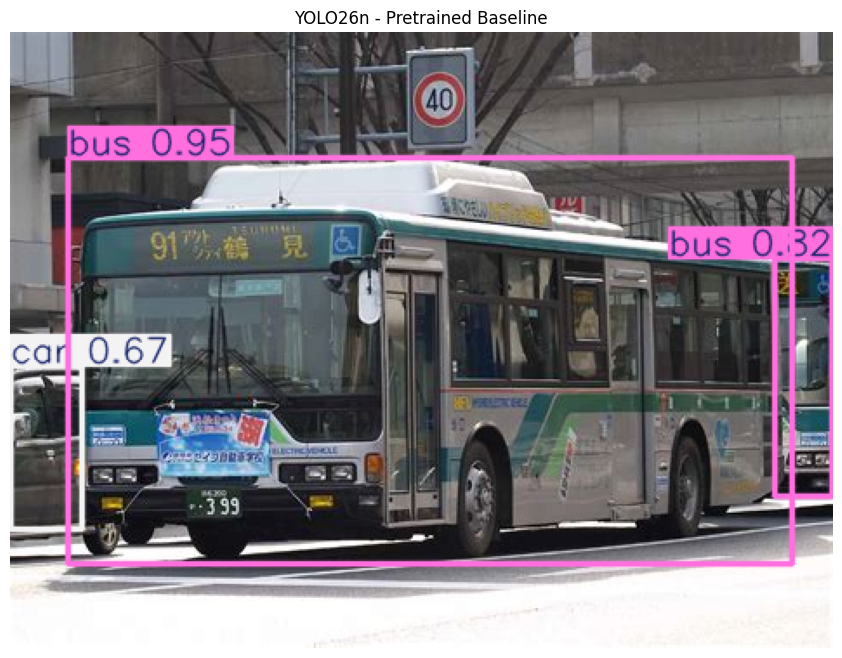

In [31]:
result = baseline_results[0]

annotated = result.plot()

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("YOLO26n - Pretrained Baseline")
plt.show()

In [33]:
model = YOLO("yolo26n.pt")

train_results = model.train(
    data=str(yaml_path),
    epochs=10,
    imgsz=416,
    batch=4,
    patience=5,
    device="cpu",
    workers=0,
    project=str(PROJECT_DIR / "runs"),
    name="vehicle_detection_cpu10",
    exist_ok=True
)

print("Training completed.")


Ultralytics 8.4.132  Python-3.13.9 torch-2.13.0+cpu CPU (AMD Ryzen 5 3500U with Radeon Vega Mobile Gfx)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\lenovo\downloads\ANPR_Traffic_AI\vechile_detection\yolo_dataset\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum

In [34]:
RUN_DIR = PROJECT_DIR / "runs" / "vehicle_detection_cpu10"

BEST_MODEL = RUN_DIR / "weights" / "best.pt"
LAST_MODEL = RUN_DIR / "weights" / "last.pt"

print("Run directory:", RUN_DIR)
print("Best model exists:", BEST_MODEL.exists())
print("Last model exists:", LAST_MODEL.exists())

Run directory: C:\Users\lenovo\downloads\ANPR_Traffic_AI\runs\vehicle_detection_cpu10
Best model exists: True
Last model exists: True


In [35]:
best_model = YOLO(str(BEST_MODEL))

print("Fine-tuned vehicle detection model loaded successfully.")

Fine-tuned vehicle detection model loaded successfully.


In [36]:
metrics = best_model.val(
    data=str(yaml_path),
    imgsz=416,
    batch=4,
    device="cpu",
    workers=0
)

print("Validation completed.")

Ultralytics 8.4.132  Python-3.13.9 torch-2.13.0+cpu CPU (AMD Ryzen 5 3500U with Radeon Vega Mobile Gfx)
YOLO26n summary (fused): 122 layers, 2,375,616 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access  (ping: 0.30.0 ms, read: 63.529.2 MB/s, size: 120.0 KB)
val: Scanning C:\Users\lenovo\Downloads\ANPR_Traffic_AI\vechile_detection\yolo_dataset\labels\val.cache... 112 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 112/112 2.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 1.7it/s 16.5s0.6s
                   all        112        113      0.748      0.754      0.838      0.708
             Ambulance         29         29      0.881      0.793      0.887       0.82
                   Bus         36         36      0.927       0.71      0.947      0.785
                   Car         17         19      0.549      0.684      0.708      0.564
                 Truck         29         29      0.633      

In [37]:
print("========== MODEL PERFORMANCE ==========")

print(f"mAP50:    {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall:    {metrics.box.mr:.4f}")

print("=======================================")

========== MODEL PERFORMANCE ==========
mAP50:    0.8382
mAP50-95: 0.7084
Precision: 0.7477
Recall:    0.7538



image 1/1 C:\Users\lenovo\downloads\ANPR_Traffic_AI\vechile_detection\BUS_123.jpeg: 320x416 1 Bus, 328.8ms
Speed: 5.8ms preprocess, 328.8ms inference, 3.1ms postprocess per image at shape (1, 3, 320, 416)


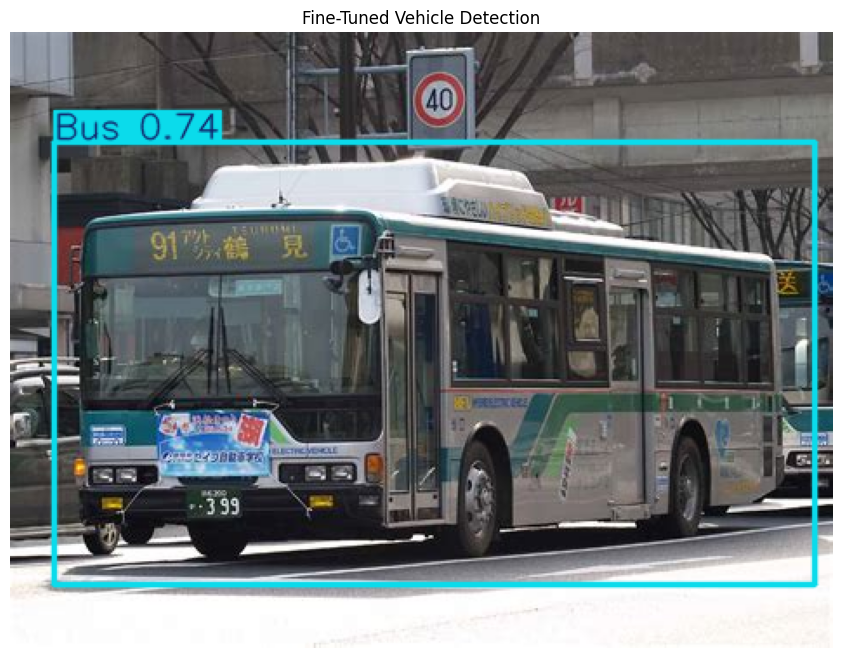

In [38]:
test_image = str(final_val_list[0])

results = best_model.predict(
    source=test_image,
    conf=0.25,
    save=False,
    device="cpu"
)

annotated = results[0].plot()

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Fine-Tuned Vehicle Detection")
plt.show()

In [39]:
sample_images = random.sample(
    final_val_list,
    min(10, len(final_val_list))
)

results = best_model.predict(
    source=[str(p) for p in sample_images],
    conf=0.25,
    save=True,
    device="cpu"
)

print("Predictions completed:", len(results))


0: 416x416 1 Bus, 113.0ms
1: 416x416 2 Buss, 113.0ms
2: 416x416 1 Truck, 113.0ms
3: 416x416 1 Truck, 113.0ms
4: 416x416 1 Car, 113.0ms
5: 416x416 2 Trucks, 113.0ms
6: 416x416 1 Truck, 113.0ms
7: 416x416 2 Buss, 113.0ms
8: 416x416 1 Ambulance, 113.0ms
9: 416x416 1 Ambulance, 1 Truck, 113.0ms
Speed: 4.2ms preprocess, 113.0ms inference, 0.9ms postprocess per image at shape (1, 3, 416, 416)
Results saved to C:\Users\lenovo\Downloads\ANPR_Traffic_AI\runs\detect\predict
Predictions completed: 10


In [40]:
FINAL_MODEL_DIR = PROJECT_DIR / "models"
FINAL_MODEL_DIR.mkdir(exist_ok=True)

FINAL_MODEL_PATH = FINAL_MODEL_DIR / "vehicle_detection_best.pt"

shutil.copy2(
    BEST_MODEL,
    FINAL_MODEL_PATH
)

print("Final model saved at:")
print(FINAL_MODEL_PATH)

Final model saved at:
C:\Users\lenovo\downloads\ANPR_Traffic_AI\models\vehicle_detection_best.pt


In [41]:
print("=" * 60)
print("       VEHICLE DETECTION MODEL - FINAL SUMMARY")
print("=" * 60)

print("Model: YOLO26n")
print("Training images:", len(final_train_list))
print("Validation images:", len(final_val_list))

print("\nClasses:")
for i, cls in enumerate(classes):
    print(f"  {i}: {cls}")

print("\nPerformance:")
print(f"mAP50:     {metrics.box.map50:.4f}")
print(f"mAP50-95:  {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall:    {metrics.box.mr:.4f}")

print("\nFinal model:")
print(FINAL_MODEL_PATH)

print("=" * 60)

       VEHICLE DETECTION MODEL - FINAL SUMMARY
Model: YOLO26n
Training images: 444
Validation images: 112

Classes:
  0: Ambulance
  1: Bus
  2: Car
  3: Truck

Performance:
mAP50:     0.8382
mAP50-95:  0.7084
Precision: 0.7477
Recall:    0.7538

Final model:
C:\Users\lenovo\downloads\ANPR_Traffic_AI\models\vehicle_detection_best.pt
